Notebook 03 — Embedding Evaluation

In [826]:
!pip install -q gensim


In [827]:
!apt-get -qq install fonts-noto

In [828]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

In [829]:
!fc-list | grep -i "gurmukhi"

/usr/share/fonts/truetype/noto/NotoSansGurmukhi-ExtraCondensedMedium.ttf: Noto Sans Gurmukhi,Noto Sans Gurmukhi ExtraCondensed Medium:style=ExtraCondensed Medium,Regular
/usr/share/fonts/truetype/noto/NotoSansGurmukhiUI-SemiCondensed.ttf: Noto Sans Gurmukhi UI,Noto Sans Gurmukhi UI SemiCondensed:style=SemiCondensed,Regular
/usr/share/fonts/truetype/noto/NotoSansGurmukhiUI-ExtraCondensedSemiBold.ttf: Noto Sans Gurmukhi UI,Noto Sans Gurmukhi UI ExtraCondensed SemiBold:style=ExtraCondensed SemiBold,Regular
/usr/share/fonts/truetype/noto/NotoSerifGurmukhi-Black.ttf: Noto Serif Gurmukhi,Noto Serif Gurmukhi Black:style=Black,Regular
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-CondensedExtraBold.ttf: Noto Sans Gurmukhi,Noto Sans Gurmukhi Condensed ExtraBold:style=Condensed ExtraBold,Regular
/usr/share/fonts/truetype/noto/NotoSerifGurmukhi-SemiBold.ttf: Noto Serif Gurmukhi,Noto Serif Gurmukhi SemiBold:style=SemiBold,Regular
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-ExtraLight.ttf: No

In [830]:
!apt-get update -qq
!apt-get install -y fonts-noto-core

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-core is already the newest version (20201225-1build1).
0 upgraded, 0 newly installed, 0 to remove and 102 not upgraded.


In [831]:
from matplotlib import font_manager

for f in font_manager.fontManager.ttflist:
    if "Gurmukhi" in f.name:
        print(f.name)
        print(f.fname)

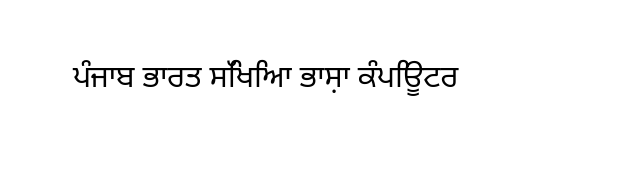

In [832]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoSansGurmukhi-Regular.ttf"
)

plt.figure(figsize=(8,2))
plt.text(
    0.1,
    0.5,
    "ਪੰਜਾਬ ਭਾਰਤ ਸਿੱਖਿਆ ਭਾਸ਼ਾ ਕੰਪਿਊਟਰ",
    fontproperties=font,
    fontsize=22
)

plt.axis("off")
plt.show()

In [833]:
available_fonts = sorted(
    {font.name for font in font_manager.fontManager.ttflist}
)

for font in available_fonts:
    if any(name.lower() in font.lower() for name in [
        "noto",
        "gurmukhi",
        "punjabi",
        "urdu",
        "arabic",
        "dejavu"
    ]):
        print(font)

DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display


In [834]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Gurmukhi
gurmukhi_font = fm.FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoSansGurmukhi-Regular.ttf"
)

# Arabic / Shahmukhi
shahmukhi_font = fm.FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf"
)


def get_font(word):
    """
    Automatically choose the correct font.
    """

    for ch in word:
        cp = ord(ch)

        # Gurmukhi
        if 0x0A00 <= cp <= 0x0A7F:
            return gurmukhi_font

        # Arabic / Shahmukhi
        if 0x0600 <= cp <= 0x06FF:
            return shahmukhi_font

    return None

print("Fonts loaded.")

Fonts loaded.


In [835]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print("Libraries loaded.")

Libraries loaded.


In [836]:
import os

print(os.listdir("/content"))

['.config', 'Figure_3_tSNE_Punjabi_Embeddings.png', 'gurmukhi_skipgram.model', 'punjabi_shahmukhi_corpus (1).txt', 'punjabi_shahmukhi_corpus_final.txt', 'shahmukhi_skipgram.model', 'gurmukhi_cbow_word2vec.model', 'evaluation_figures', 'Figure_2_PCA_Punjabi_Embeddings.png', 'evaluation_results', 'punjabi_shahmukhi_word2vec_final.model', 'shahmukhi_cbow.model', 'punjabi_gurmukhi_corpus.txt', 'punjabi_gurmukhi_corpus_cleaned.txt', 'gurmukhi_cbow.model', 'sample_data']


In [837]:
GURMUKHI_CBOW = "/content/gurmukhi_cbow.model"
GURMUKHI_SKIPGRAM = "/content/gurmukhi_skipgram.model"

SHAHMUKHI_CBOW = "/content/shahmukhi_cbow.model"
SHAHMUKHI_SKIPGRAM = "/content/shahmukhi_skipgram.model"

In [838]:
gurmukhi_cbow = Word2Vec.load(GURMUKHI_CBOW)

gurmukhi_skipgram = Word2Vec.load(GURMUKHI_SKIPGRAM)

shahmukhi_cbow = Word2Vec.load(SHAHMUKHI_CBOW)

shahmukhi_skipgram = Word2Vec.load(SHAHMUKHI_SKIPGRAM)

print("✅ All four models loaded successfully.")

✅ All four models loaded successfully.


In [839]:
summary = pd.DataFrame({

    "Model":[
        "Gurmukhi CBOW",
        "Gurmukhi SkipGram",
        "Shahmukhi CBOW",
        "Shahmukhi SkipGram"
    ],

    "Vocabulary":[
        len(gurmukhi_cbow.wv),
        len(gurmukhi_skipgram.wv),
        len(shahmukhi_cbow.wv),
        len(shahmukhi_skipgram.wv)
    ],

    "Dimensions":[
        gurmukhi_cbow.vector_size,
        gurmukhi_skipgram.vector_size,
        shahmukhi_cbow.vector_size,
        shahmukhi_skipgram.vector_size
    ]

})

summary

,Model,Vocabulary,Dimensions
0,Gurmukhi CBOW,10049,200
1,Gurmukhi SkipGram,10049,200
2,Shahmukhi CBOW,12694,200
3,Shahmukhi SkipGram,12694,200


In [840]:
# ============================================
# Save Model Summary
# ============================================

RESULTS_DIR = "/content/evaluation_results"
FIGURES_DIR = "/content/evaluation_figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

summary.to_csv(
    f"{RESULTS_DIR}/model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Model summary saved.")

✅ Model summary saved.


In [841]:
!pip install -q arabic-reshaper python-bidi

In [842]:
import arabic_reshaper
from bidi.algorithm import get_display

In [843]:
def prepare_label(word):
    """
    Prepare Gurmukhi and Shahmukhi labels for Matplotlib.
    Shahmukhi text is reshaped and displayed right-to-left.
    """

    for character in word:
        codepoint = ord(character)

        # Arabic/Shahmukhi Unicode ranges
        if (
            0x0600 <= codepoint <= 0x06FF
            or 0x0750 <= codepoint <= 0x077F
            or 0x08A0 <= codepoint <= 0x08FF
        ):
            reshaped_word = arabic_reshaper.reshape(word)
            return get_display(reshaped_word)

    # Gurmukhi and English do not need reshaping
    return word

In [844]:
import os

model_files = [
    GURMUKHI_CBOW,
    GURMUKHI_SKIPGRAM,
    SHAHMUKHI_CBOW,
    SHAHMUKHI_SKIPGRAM
]

for file in model_files:
    assert os.path.exists(file), f"Missing model: {file}"

print("✅ All model files found.")

✅ All model files found.


In [845]:
# ============================================
# Cell 9: Evaluation Word Set
# ============================================

evaluation_words = [
    {
        "Category": "Country",
        "Gurmukhi": "ਭਾਰਤ",
        "Shahmukhi": "بھارت"
    },
    {
        "Category": "Country",
        "Gurmukhi": "ਪਾਕਿਸਤਾਨ",
        "Shahmukhi": "پاکستان"
    },
    {
        "Category": "Religion",
        "Gurmukhi": "ਸਿੱਖ",
        "Shahmukhi": "سکھ"
    },
    {
        "Category": "Religious figure",
        "Gurmukhi": "ਗੁਰੂ",
        "Shahmukhi": "گرو"
    },
    {
        "Category": "Person",
        "Gurmukhi": "ਨਾਨਕ",
        "Shahmukhi": "نانک"
    },
    {
        "Category": "City",
        "Gurmukhi": "ਮੁੰਬਈ",
        "Shahmukhi": "مںبی"
    }
]

evaluation_df = pd.DataFrame(evaluation_words)
evaluation_df

,Category,Gurmukhi,Shahmukhi
0,Country,ਭਾਰਤ,بھارت
1,Country,ਪਾਕਿਸਤਾਨ,پاکستان
2,Religion,ਸਿੱਖ,سکھ
3,Religious figure,ਗੁਰੂ,گرو
4,Person,ਨਾਨਕ,نانک
5,City,ਮੁੰਬਈ,مںبی


In [846]:
# ============================================
# Cell 10: Check Evaluation Word Coverage
# ============================================

coverage_rows = []

for item in evaluation_words:
    g_word = item["Gurmukhi"]
    s_word = item["Shahmukhi"]

    coverage_rows.append({
        "Category": item["Category"],
        "Gurmukhi Word": g_word,
        "Gurmukhi CBOW": g_word in gurmukhi_cbow.wv,
        "Gurmukhi Skip-gram": g_word in gurmukhi_skipgram.wv,
        "Shahmukhi Word": s_word,
        "Shahmukhi CBOW": s_word in shahmukhi_cbow.wv,
        "Shahmukhi Skip-gram": s_word in shahmukhi_skipgram.wv
    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df

,Category,Gurmukhi Word,Gurmukhi CBOW,Gurmukhi Skip-gram,Shahmukhi Word,Shahmukhi CBOW,Shahmukhi Skip-gram
0,Country,ਭਾਰਤ,True,True,بھارت,True,True
1,Country,ਪਾਕਿਸਤਾਨ,True,True,پاکستان,True,True
2,Religion,ਸਿੱਖ,True,True,سکھ,True,True
3,Religious figure,ਗੁਰੂ,True,True,گرو,True,True
4,Person,ਨਾਨਕ,True,True,نانک,True,True
5,City,ਮੁੰਬਈ,True,True,مںبی,True,True


In [847]:
# ============================================
# Cell 11: Nearest-Neighbor Function
# ============================================

def get_nearest_neighbors(
    model,
    query_word,
    model_name,
    category,
    topn=5
):
    if query_word not in model.wv:
        return [{
            "Category": category,
            "Model": model_name,
            "Query": query_word,
            "Rank": None,
            "Neighbor": "OOV",
            "Similarity": np.nan
        }]

    neighbors = model.wv.most_similar(
        query_word,
        topn=topn
    )

    rows = []

    for rank, (neighbor, score) in enumerate(
        neighbors,
        start=1
    ):
        rows.append({
            "Category": category,
            "Model": model_name,
            "Query": query_word,
            "Rank": rank,
            "Neighbor": neighbor,
            "Similarity": round(score, 4)
        })

    return rows

In [848]:
# ============================================
# Cell 12: Run Nearest-Neighbor Evaluation
# ============================================

all_neighbor_rows = []

for item in evaluation_words:
    category = item["Category"]
    g_word = item["Gurmukhi"]
    s_word = item["Shahmukhi"]

    all_neighbor_rows.extend(
        get_nearest_neighbors(
            gurmukhi_cbow,
            g_word,
            "Gurmukhi CBOW",
            category
        )
    )

    all_neighbor_rows.extend(
        get_nearest_neighbors(
            gurmukhi_skipgram,
            g_word,
            "Gurmukhi Skip-gram",
            category
        )
    )

    all_neighbor_rows.extend(
        get_nearest_neighbors(
            shahmukhi_cbow,
            s_word,
            "Shahmukhi CBOW",
            category
        )
    )

    all_neighbor_rows.extend(
        get_nearest_neighbors(
            shahmukhi_skipgram,
            s_word,
            "Shahmukhi Skip-gram",
            category
        )
    )

nearest_neighbors_df = pd.DataFrame(
    all_neighbor_rows
)

nearest_neighbors_df

,Category,Model,Query,Rank,Neighbor,Similarity
0,Country,Gurmukhi CBOW,ਭਾਰਤ,1,ਭਾਰਤੀ,0.5509
1,Country,Gurmukhi CBOW,ਭਾਰਤ,2,ਪਾਕਿਸਤਾਨ,0.4855
2,Country,Gurmukhi CBOW,ਭਾਰਤ,3,ਪ੍ਰਦੇਸ਼,0.4758
3,Country,Gurmukhi CBOW,ਭਾਰਤ,4,ਪਾਕਿਸਤਾਨੀ,0.4602
4,Country,Gurmukhi CBOW,ਭਾਰਤ,5,ਅਫਗਾਨਿਸਤਾਨ,0.4558
...,...,...,...,...,...,...
115,City,Shahmukhi Skip-gram,مںبی,1,انڈیانج,0.6640
116,City,Shahmukhi Skip-gram,مںبی,2,اںڈیانج,0.6472
117,City,Shahmukhi Skip-gram,مںبی,3,ڈےارڈےولج,0.6445
118,City,Shahmukhi Skip-gram,مںبی,4,رایڈرج,0.6170


In [849]:
# ============================================
# Cell 13: Save Evaluation Results
# ============================================

coverage_df.to_csv(
    f"{RESULTS_DIR}/evaluation_word_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

nearest_neighbors_df.to_csv(
    f"{RESULTS_DIR}/nearest_neighbors_all_models.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Coverage and nearest-neighbor results saved.")

✅ Coverage and nearest-neighbor results saved.


In [850]:
# ============================================
# Cell 14: Cosine Similarity Function
# ============================================

def cosine_similarity_table(
    model,
    word_pairs,
    model_name
):
    rows = []

    for word1, word2 in word_pairs:

        if word1 in model.wv and word2 in model.wv:
            similarity = model.wv.similarity(word1, word2)
        else:
            similarity = np.nan

        rows.append({
            "Model": model_name,
            "Word 1": word1,
            "Word 2": word2,
            "Cosine Similarity": (
                round(similarity, 4)
                if not np.isnan(similarity)
                else np.nan
            )
        })

    return pd.DataFrame(rows)

In [851]:
# ============================================
# Cell 15: Evaluation Word Pairs
# ============================================

gurmukhi_pairs = [
    ("ਭਾਰਤ", "ਪਾਕਿਸਤਾਨ"),
    ("ਗੁਰੂ", "ਨਾਨਕ"),
    ("ਸਿੱਖ", "ਗੁਰੂ"),
    ("ਭਾਰਤ", "ਸਿੱਖ"),
]

shahmukhi_pairs = [
    ("بھارت", "پاکستان"),
    ("گرو", "نانک"),
    ("سکھ", "گرو"),
    ("بھارت", "سکھ"),
]

In [852]:
# ============================================
# Cell 16: Cosine Similarity Evaluation
# ============================================

cosine_results = pd.concat([

    cosine_similarity_table(
        gurmukhi_cbow,
        gurmukhi_pairs,
        "Gurmukhi CBOW"
    ),

    cosine_similarity_table(
        gurmukhi_skipgram,
        gurmukhi_pairs,
        "Gurmukhi Skip-gram"
    ),

    cosine_similarity_table(
        shahmukhi_cbow,
        shahmukhi_pairs,
        "Shahmukhi CBOW"
    ),

    cosine_similarity_table(
        shahmukhi_skipgram,
        shahmukhi_pairs,
        "Shahmukhi Skip-gram"
    )

], ignore_index=True)

cosine_results

,Model,Word 1,Word 2,Cosine Similarity
0,Gurmukhi CBOW,ਭਾਰਤ,ਪਾਕਿਸਤਾਨ,0.4855
1,Gurmukhi CBOW,ਗੁਰੂ,ਨਾਨਕ,0.2150
2,Gurmukhi CBOW,ਸਿੱਖ,ਗੁਰੂ,0.1983
3,Gurmukhi CBOW,ਭਾਰਤ,ਸਿੱਖ,0.1713
4,Gurmukhi Skip-gram,ਭਾਰਤ,ਪਾਕਿਸਤਾਨ,0.3598
5,Gurmukhi Skip-gram,ਗੁਰੂ,ਨਾਨਕ,0.5295
6,Gurmukhi Skip-gram,ਸਿੱਖ,ਗੁਰੂ,0.3555
7,Gurmukhi Skip-gram,ਭਾਰਤ,ਸਿੱਖ,0.1865
8,Shahmukhi CBOW,بھارت,پاکستان,0.4131
9,Shahmukhi CBOW,گرو,نانک,0.0522


In [853]:
# ============================================
# Cell 17: Save Cosine Similarity Results
# ============================================

cosine_results.to_csv(
    f"{RESULTS_DIR}/cosine_similarity_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Cosine similarity results saved.")

✅ Cosine similarity results saved.


In [854]:
# ============================================
# Cell 18: PCA Visualization Function
# ============================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def plot_pca_embeddings(
    model,
    words,
    title,
    output_file
):
    """
    Create a 2D PCA plot for selected words.
    Only words available in the model vocabulary are used.
    """

    available_words = [
        word
        for word in words
        if word in model.wv
    ]

    if len(available_words) < 2:
        print(
            f"Not enough in-vocabulary words for: {title}"
        )
        return

    vectors = np.array([
        model.wv[word]
        for word in available_words
    ])

    pca = PCA(n_components=2)
    coordinates = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))

    plt.scatter(
        coordinates[:, 0],
        coordinates[:, 1]
    )

    for index, word in enumerate(available_words):
        display_word = prepare_label(word)

        plt.annotate(
            display_word,
            (
                coordinates[index, 0],
                coordinates[index, 1]
            ),
            fontsize=11,
            fontproperties=get_font(word)
        )

    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_file)

In [855]:
# ============================================
# Cell 19: PCA Word Sets
# ============================================

gurmukhi_pca_words = [
    "ਭਾਰਤ",
    "ਪਾਕਿਸਤਾਨ",
    "ਸਿੱਖ",
    "ਗੁਰੂ",
    "ਨਾਨਕ",
    "ਮੁੰਬਈ"
]

shahmukhi_pca_words = [
    "بھارت",
    "پاکستان",
    "سکھ",
    "گرو",
    "نانک",
    "مںبی"
]

/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)


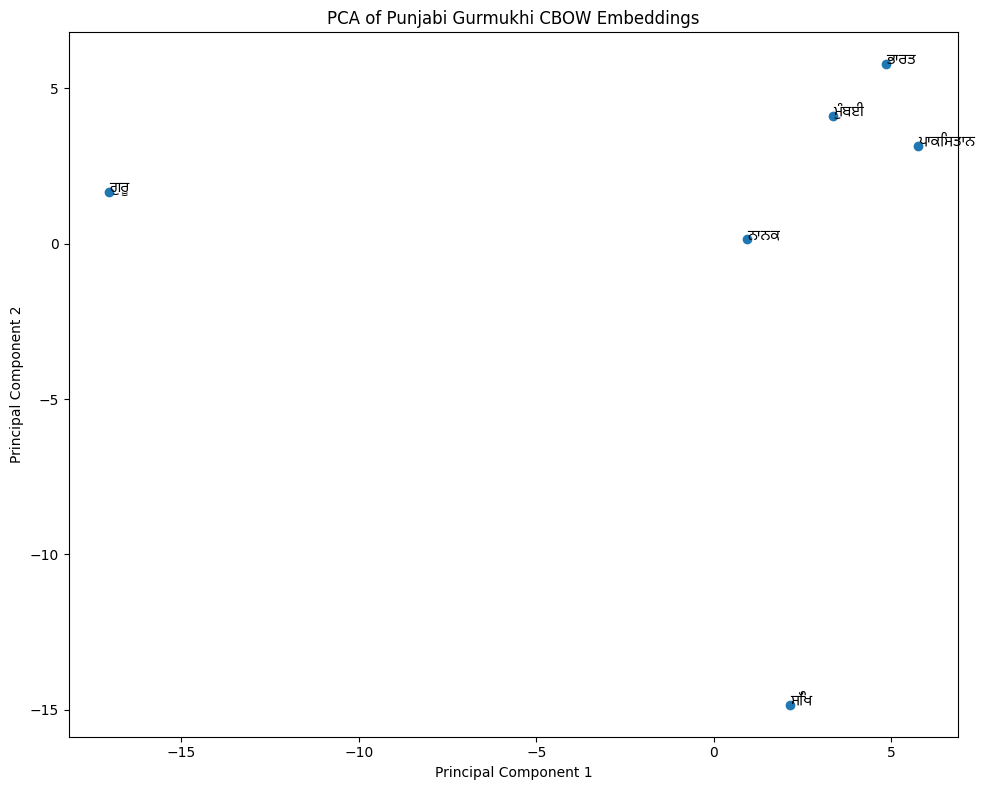

Saved: /content/evaluation_figures/gurmukhi_cbow_pca.png


In [856]:
# ============================================
# Cell 20: Gurmukhi CBOW PCA
# ============================================

plot_pca_embeddings(
    gurmukhi_cbow,
    gurmukhi_pca_words,
    "PCA of Punjabi Gurmukhi CBOW Embeddings",
    f"{FIGURES_DIR}/gurmukhi_cbow_pca.png"
)

/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)


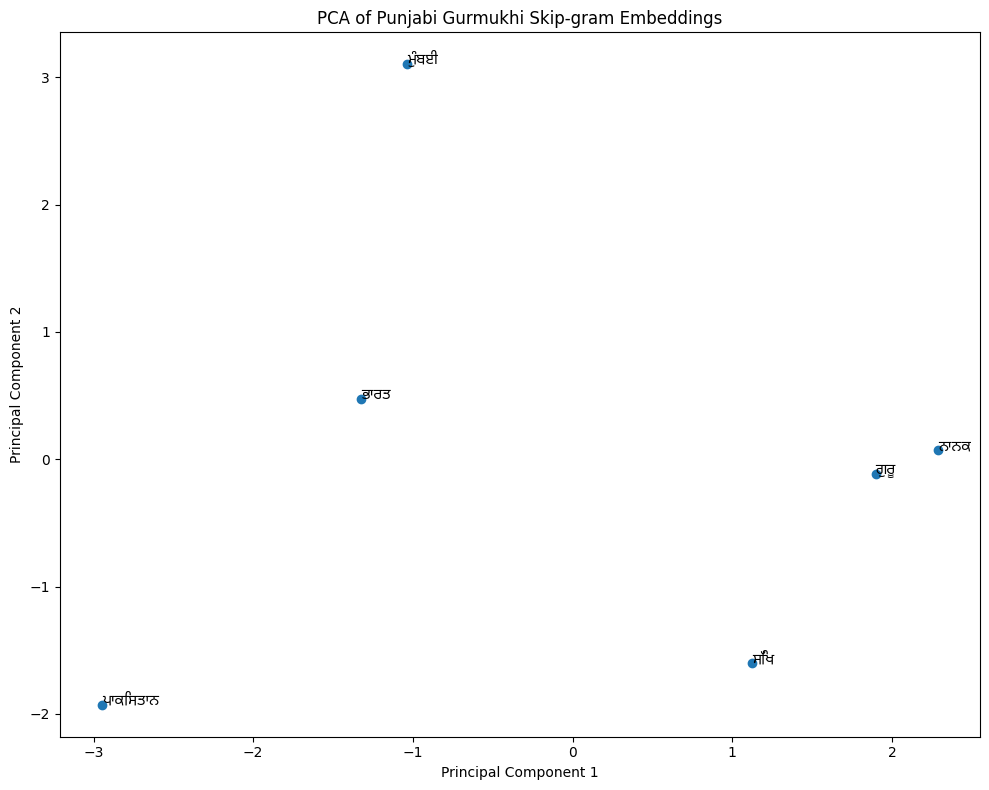

Saved: /content/evaluation_figures/gurmukhi_skipgram_pca.png


In [857]:
# ============================================
# Cell 21: Gurmukhi Skip-gram PCA
# ============================================

plot_pca_embeddings(
    gurmukhi_skipgram,
    gurmukhi_pca_words,
    "PCA of Punjabi Gurmukhi Skip-gram Embeddings",
    f"{FIGURES_DIR}/gurmukhi_skipgram_pca.png"
)

/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


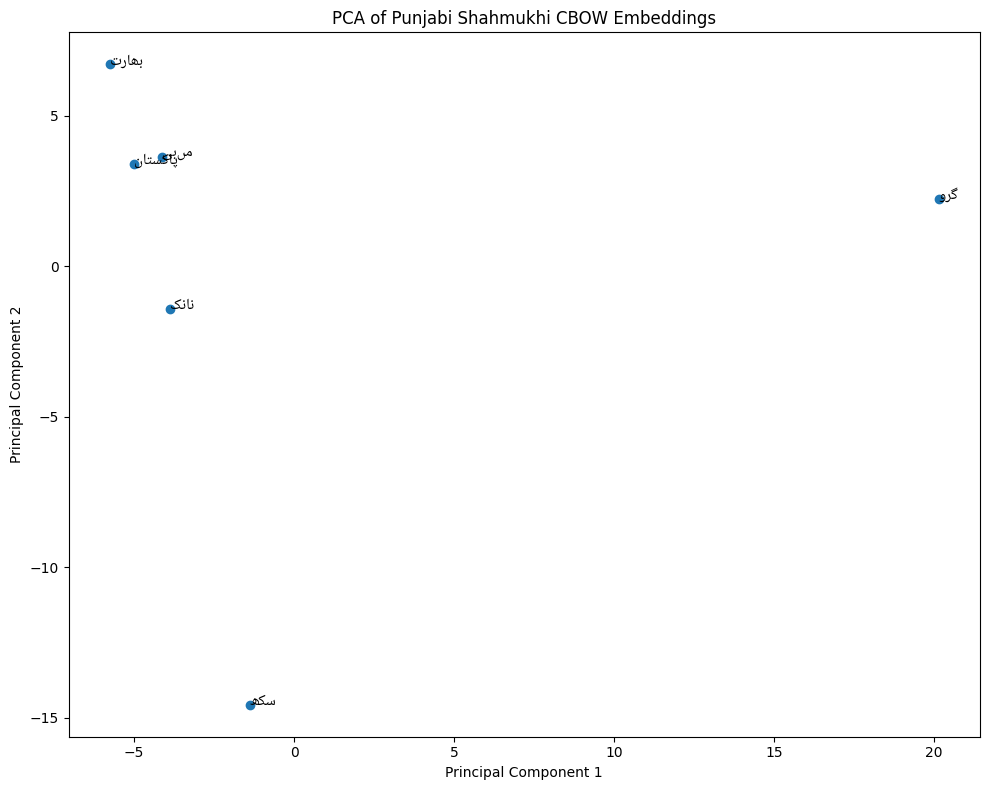

Saved: /content/evaluation_figures/shahmukhi_cbow_pca.png


In [858]:
# ============================================
# Cell 22: Shahmukhi CBOW PCA
# ============================================

plot_pca_embeddings(
    shahmukhi_cbow,
    shahmukhi_pca_words,
    "PCA of Punjabi Shahmukhi CBOW Embeddings",
    f"{FIGURES_DIR}/shahmukhi_cbow_pca.png"
)

/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:63: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/tmp/ipykernel_23808/1515084098.py:65: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


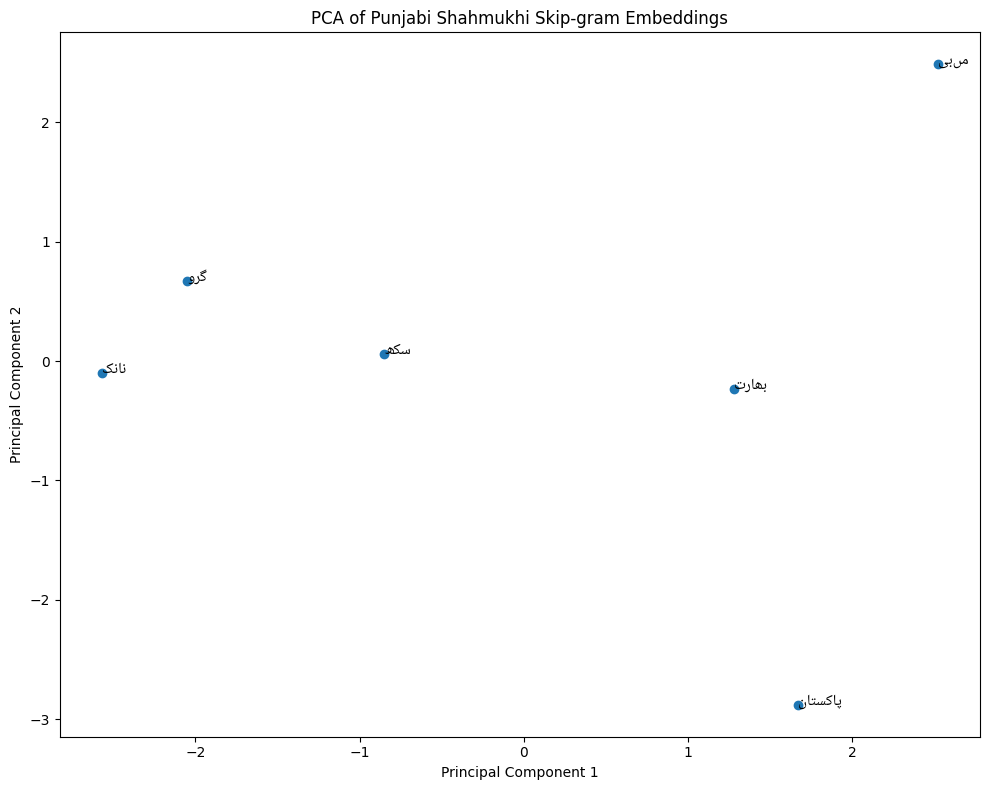

Saved: /content/evaluation_figures/shahmukhi_skipgram_pca.png


In [859]:
# ============================================
# Cell 23: Shahmukhi Skip-gram PCA
# ============================================

plot_pca_embeddings(
    shahmukhi_skipgram,
    shahmukhi_pca_words,
    "PCA of Punjabi Shahmukhi Skip-gram Embeddings",
    f"{FIGURES_DIR}/shahmukhi_skipgram_pca.png"
)

In [860]:
# ============================================
# Cell 24: t-SNE Visualization Function
# ============================================

from sklearn.manifold import TSNE


def plot_tsne_embeddings(
    model,
    words,
    title,
    output_file,
    random_state=42
):
    """
    Create a 2D t-SNE plot for selected words.
    Only words present in the model vocabulary are used.
    """

    available_words = [
        word
        for word in words
        if word in model.wv
    ]

    if len(available_words) < 3:
        print(
            f"Not enough in-vocabulary words for: {title}"
        )
        return

    vectors = np.array([
        model.wv[word]
        for word in available_words
    ])

    # Perplexity must be smaller than the number of samples.
    perplexity_value = min(
        3,
        len(available_words) - 1
    )

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity_value,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=random_state
    )

    coordinates = tsne.fit_transform(vectors)

    plt.figure(figsize=(10, 8))

    plt.scatter(
        coordinates[:, 0],
        coordinates[:, 1]
    )

    for index, word in enumerate(available_words):
        display_word = prepare_label(word)

        plt.annotate(
            display_word,
            (
                coordinates[index, 0],
                coordinates[index, 1]
            ),
            fontsize=11,
            fontproperties=get_font(word)
        )

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_file)
    print("Words plotted:", len(available_words))
    print("Perplexity:", perplexity_value)

/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)


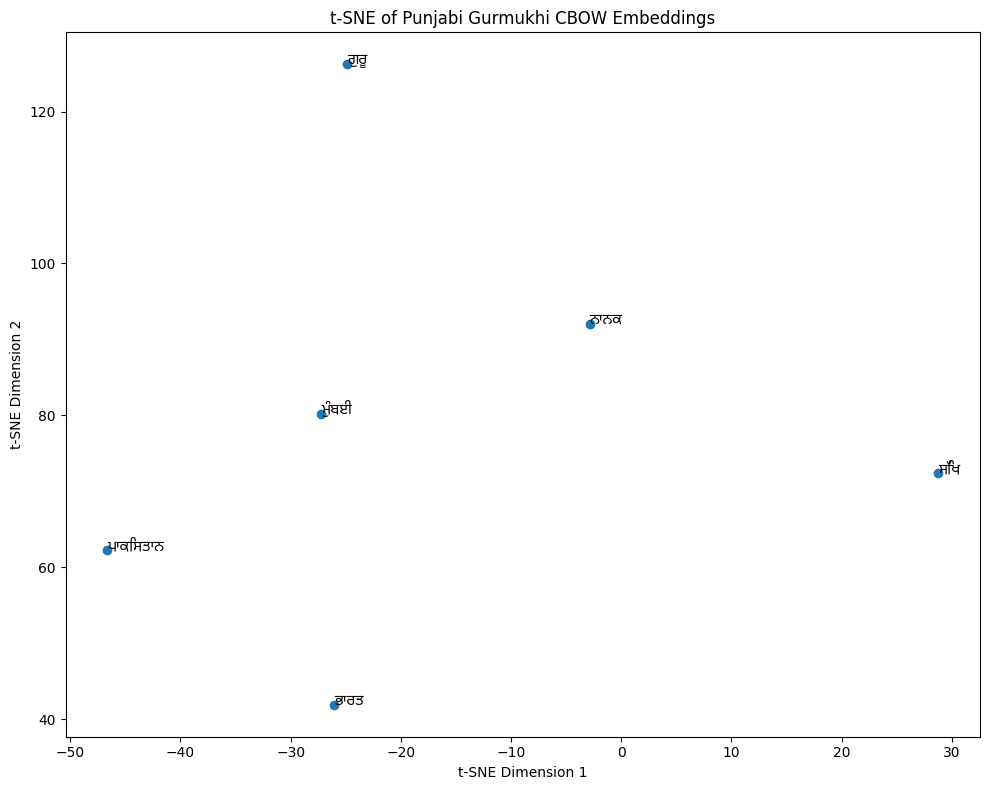

Saved: /content/evaluation_figures/gurmukhi_cbow_tsne.png
Words plotted: 6
Perplexity: 3


In [861]:
# ============================================
# Cell 25: Gurmukhi CBOW t-SNE
# ============================================

plot_tsne_embeddings(
    gurmukhi_cbow,
    gurmukhi_pca_words,
    "t-SNE of Punjabi Gurmukhi CBOW Embeddings",
    f"{FIGURES_DIR}/gurmukhi_cbow_tsne.png"
)

/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)


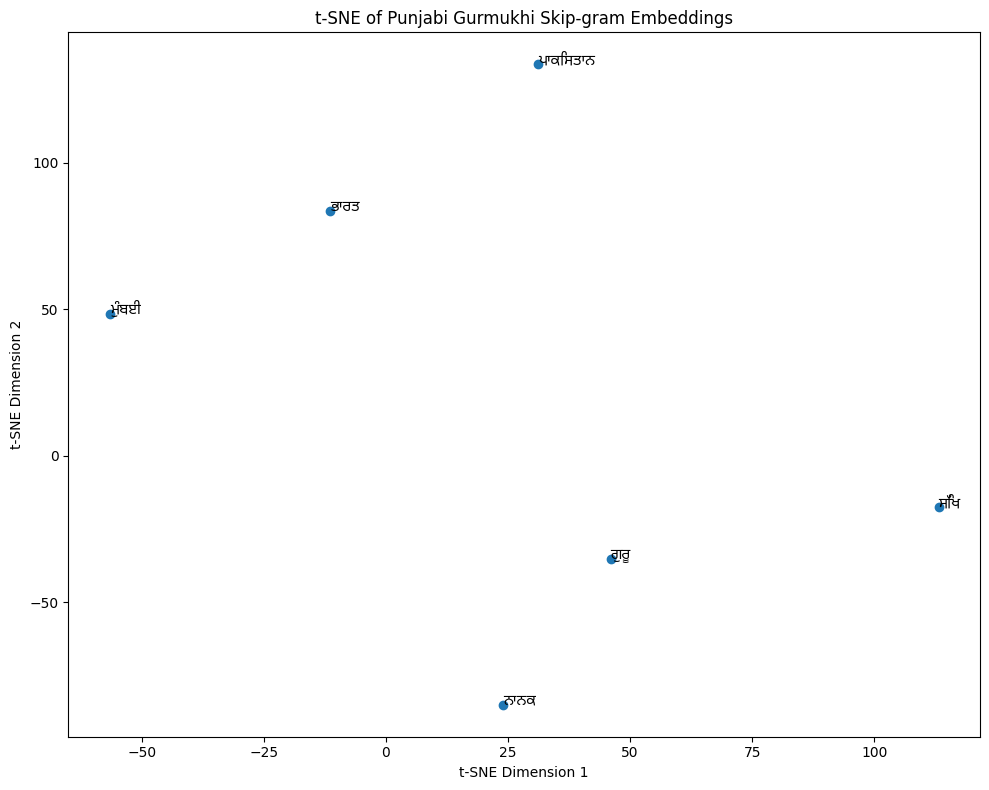

Saved: /content/evaluation_figures/gurmukhi_skipgram_tsne.png
Words plotted: 6
Perplexity: 3


In [862]:
# ============================================
# Cell 26: Gurmukhi Skip-gram t-SNE
# ============================================

plot_tsne_embeddings(
    gurmukhi_skipgram,
    gurmukhi_pca_words,
    "t-SNE of Punjabi Gurmukhi Skip-gram Embeddings",
    f"{FIGURES_DIR}/gurmukhi_skipgram_tsne.png"
)

/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.canvas.print_figure(bytes_io, **kw)


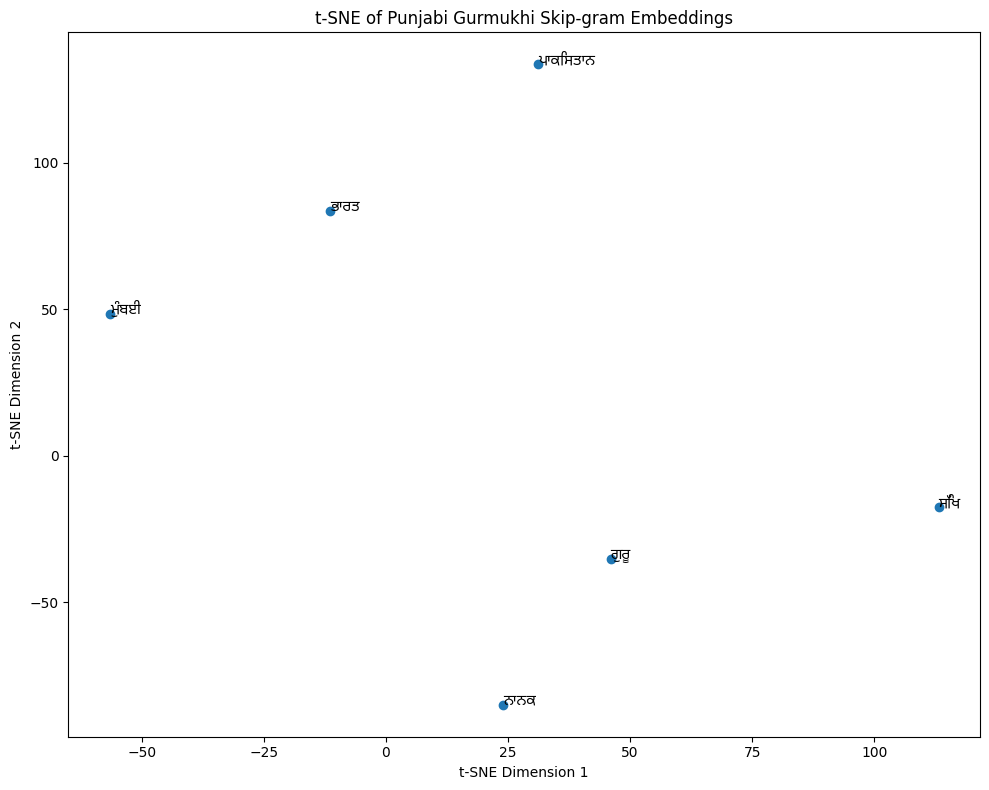

Saved: /content/evaluation_figures/gurmukhi_skipgram_tsne.png
Words plotted: 6
Perplexity: 3


In [863]:
# ============================================
# Cell 26: Gurmukhi Skip-gram t-SNE
# ============================================

plot_tsne_embeddings(
    gurmukhi_skipgram,
    gurmukhi_pca_words,
    "t-SNE of Punjabi Gurmukhi Skip-gram Embeddings",
    f"{FIGURES_DIR}/gurmukhi_skipgram_tsne.png"
)

/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


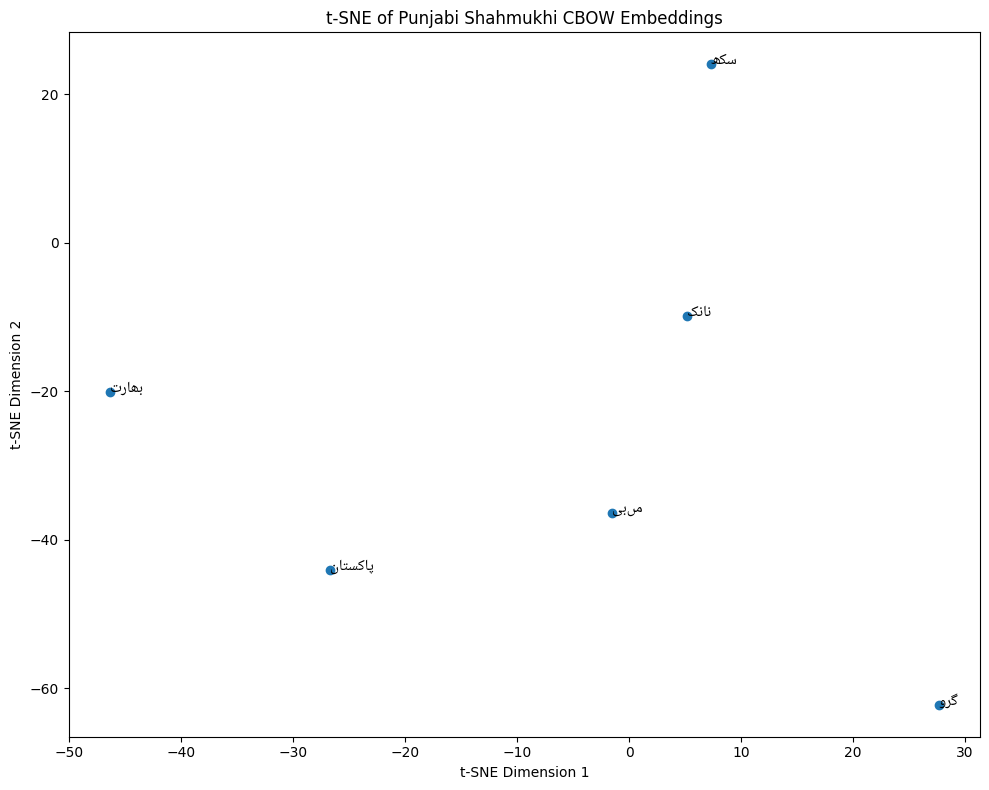

Saved: /content/evaluation_figures/shahmukhi_cbow_tsne.png
Words plotted: 6
Perplexity: 3


In [864]:
# ============================================
# Cell 27: Shahmukhi CBOW t-SNE
# ============================================

plot_tsne_embeddings(
    shahmukhi_cbow,
    shahmukhi_pca_words,
    "t-SNE of Punjabi Shahmukhi CBOW Embeddings",
    f"{FIGURES_DIR}/shahmukhi_cbow_tsne.png"
)

/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:77: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/tmp/ipykernel_23808/3492855768.py:79: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


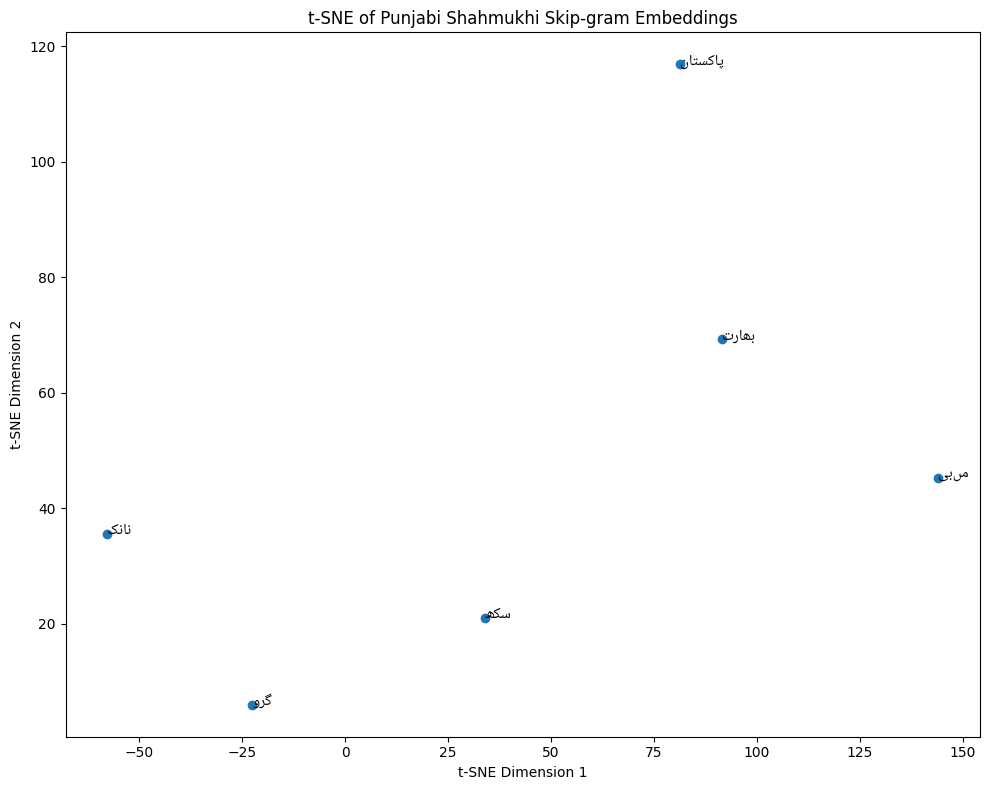

Saved: /content/evaluation_figures/shahmukhi_skipgram_tsne.png
Words plotted: 6
Perplexity: 3


In [865]:
# ============================================
# Cell 28: Shahmukhi Skip-gram t-SNE
# ============================================

plot_tsne_embeddings(
    shahmukhi_skipgram,
    shahmukhi_pca_words,
    "t-SNE of Punjabi Shahmukhi Skip-gram Embeddings",
    f"{FIGURES_DIR}/shahmukhi_skipgram_tsne.png"
)

In [866]:
# ============================================
# Cell 29: Verify Saved Figures
# ============================================

for filename in sorted(os.listdir(FIGURES_DIR)):
    path = os.path.join(FIGURES_DIR, filename)

    print(
        filename,
        round(
            os.path.getsize(path) / 1024,
            2
        ),
        "KB"
    )

gurmukhi_cbow_pca.png 107.95 KB
gurmukhi_cbow_tsne.png 113.34 KB
gurmukhi_skipgram_pca.png 105.93 KB
gurmukhi_skipgram_tsne.png 107.55 KB
shahmukhi_cbow_pca.png 109.67 KB
shahmukhi_cbow_tsne.png 112.82 KB
shahmukhi_skipgram_pca.png 107.07 KB
shahmukhi_skipgram_tsne.png 116.2 KB


In [867]:
gurmukhi_pca_words = [
    "ਭਾਰਤ",
    "ਪਾਕਿਸਤਾਨ",
    "ਸਿੱਖ",
    "ਗੁਰੂ",
    "ਨਾਨਕ",
    "ਮੁੰਬਈ",
    "ਪੰਜਾਬੀ",
    "ਸੂਬਾ",
    "ਜ਼ਿਲ੍ਹਾ",
    "ਹਰਿਆਣਾ",
    "ਦਿੱਲੀ",
    "ਲਾਹੌਰ",
    "ਭਾਸ਼ਾ",
    "ਦੇਸ਼",
    "ਲੋਕ"
]

In [868]:
def select_words(model, n_words=80, min_length=2):
    """
    Select frequent words from a Gensim Word2Vec model.
    """
    selected = []

    # index_to_key is normally ordered by frequency
    for word in model.wv.index_to_key:
        word = word.strip()

        # Remove very short tokens, numbers, and punctuation
        if (
            len(word) >= min_length
            and not word.isdigit()
            and any(char.isalpha() for char in word)
        ):
            selected.append(word)

        if len(selected) == n_words:
            break

    return selected

In [869]:
gurmukhi_words = select_words(gurmukhi_cbow, n_words=80)
shahmukhi_words = select_words(shahmukhi_cbow, n_words=80)

print("Gurmukhi words:", len(gurmukhi_words))
print(gurmukhi_words[:20])

print("Shahmukhi words:", len(shahmukhi_words))
print(shahmukhi_words[:20])

Gurmukhi words: 80
['ਦੇ', 'ਦਾ', 'ਵਿੱਚ', 'ਹੈ', 'ਅਤੇ', 'ਦੀ', 'ਨੂੰ', 'ਨੇ', 'ਤੋਂ', 'ਤੇ', 'ਇੱਕ', 'ਸੀ', 'ਇਸ', 'ਹਨ', 'ਜਨਮ', 'ਸਿੰਘ', 'ਨਾਲ', 'ਇਹ', 'ਵੀ', 'ਸ਼੍ਰੇਣੀ']
Shahmukhi words: 80
['دے', 'وچ', 'ہے', 'اتے', 'دا', 'دی', 'نوں', 'اس', 'نے', 'اک', 'ہن', 'توں', 'اہ', 'سی', 'تے', 'نال', 'وی', 'سںگھ', 'لی', 'جنم']


In [870]:
gurmukhi_words = [
    word for word in gurmukhi_words
    if word in gurmukhi_cbow.wv and word in gurmukhi_skipgram.wv
]

shahmukhi_words = [
    word for word in shahmukhi_words
    if word in shahmukhi_cbow.wv and word in shahmukhi_skipgram.wv
]

print(len(gurmukhi_words))
print(len(shahmukhi_words))

80
80


/tmp/ipykernel_23808/2224215934.py:92: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/2224215934.py:92: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/2224215934.py:92: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
/tmp/ipykernel_23808/2224215934.py:92: UserWarning: Glyph 112 (p) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
/tmp/ipykernel_23808/2224215934.py:94: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/2224215934.py:94: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.savefig(
/tmp/ipykernel_23808/2224215934.py:94: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  plt.savefig(
/tmp/ipykernel_23808/2224215934.py:94: UserWarning: Glyph 112 (p) missing from font(s) Noto Nastaliq Urdu.
  plt.savefig(


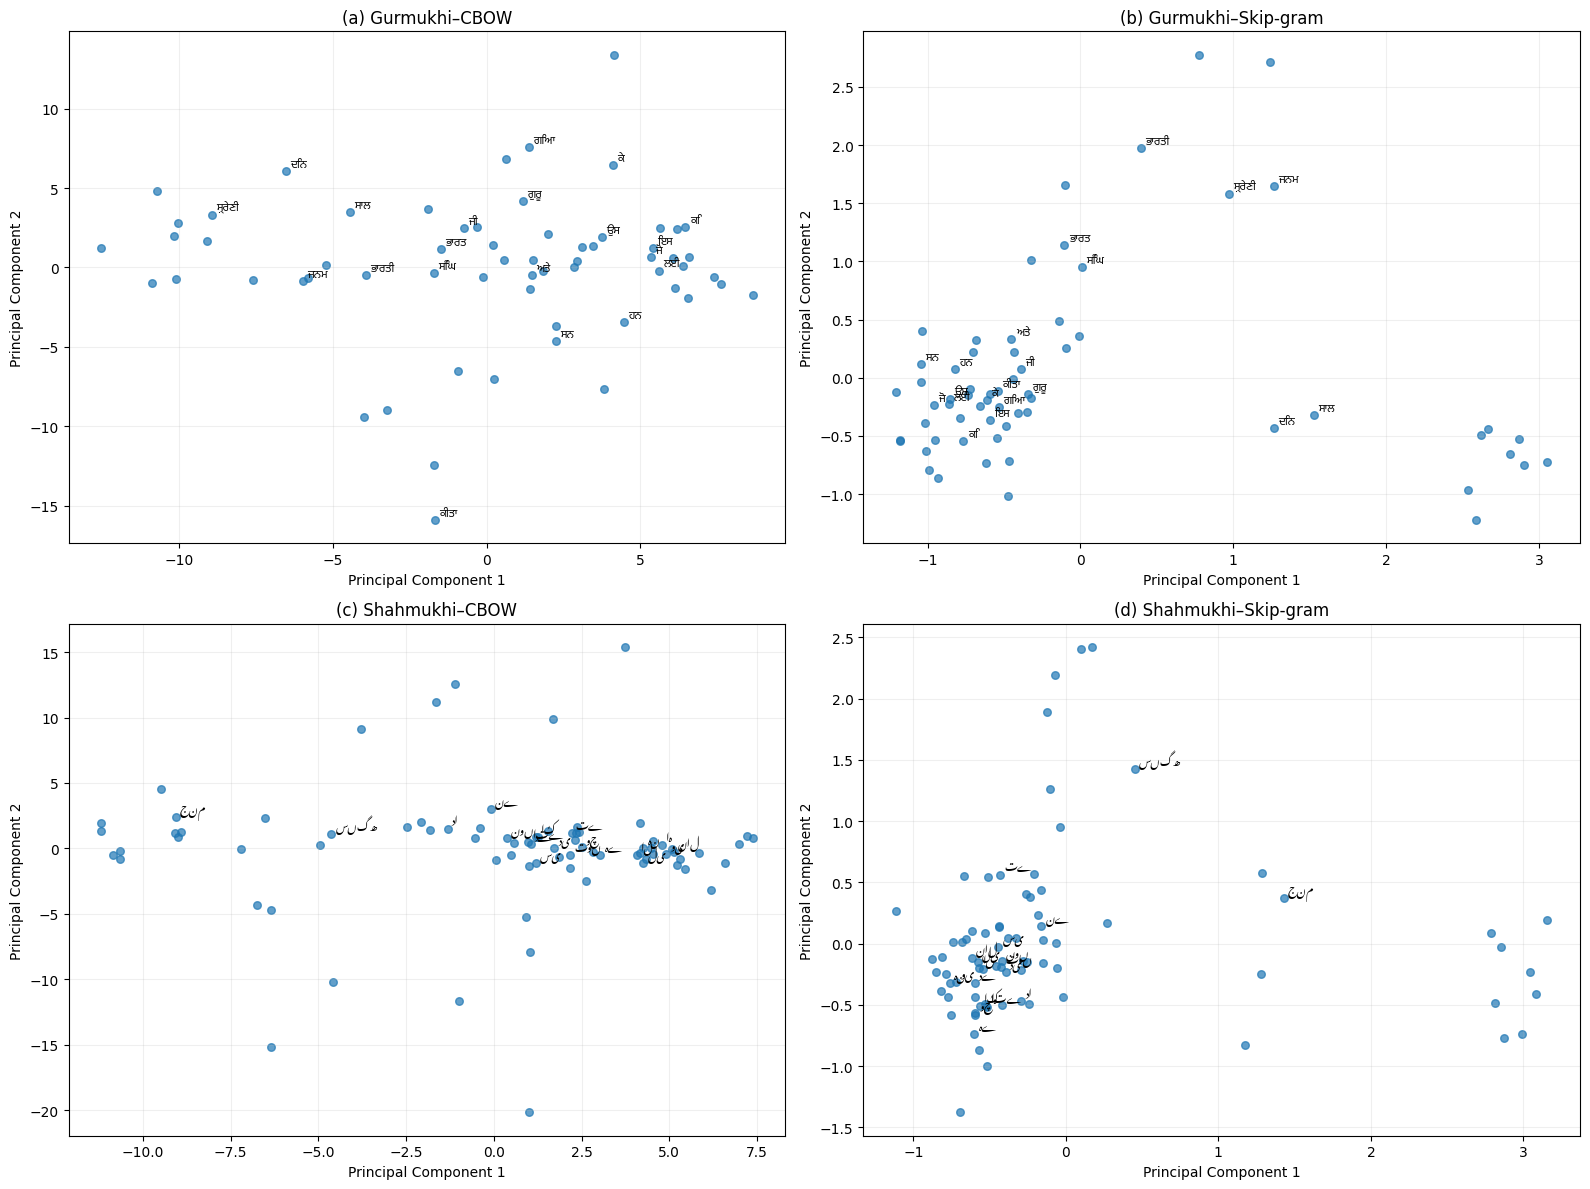

In [880]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from sklearn.decomposition import PCA

# Font paths (Google Colab)
GURMUKHI_FONT = FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoSansGurmukhi-Regular.ttf"
)

SHAHMUKHI_FONT = FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoNastaliqUrdu-Regular.ttf"
)


def plot_pca_panel(
    ax,
    model,
    words,
    title,
    script,
    label_count=20
):
    vectors = np.array([model.wv[word] for word in words])

    pca = PCA(n_components=2)
    coordinates = pca.fit_transform(vectors)

    ax.scatter(
        coordinates[:,0],
        coordinates[:,1],
        alpha=0.7,
        s=30
    )

    label_font = (
        GURMUKHI_FONT
        if script == "gurmukhi"
        else SHAHMUKHI_FONT
    )

    for i, word in enumerate(words[:label_count]):
        ax.annotate(
            word,
            (coordinates[i,0], coordinates[i,1]),
            fontsize=8,
            fontproperties=label_font,
            xytext=(3,3),
            textcoords="offset points"
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(2,2,figsize=(16,12))

plot_pca_panel(
    axes[0,0],
    gurmukhi_cbow,
    gurmukhi_words,
    "(a) Gurmukhi–CBOW",
    script="gurmukhi"
)

plot_pca_panel(
    axes[0,1],
    gurmukhi_skipgram,
    gurmukhi_words,
    "(b) Gurmukhi–Skip-gram",
    script="gurmukhi"
)

plot_pca_panel(
    axes[1,0],
    shahmukhi_cbow,
    shahmukhi_words,
    "(c) Shahmukhi–CBOW",
    script="shahmukhi"
)

plot_pca_panel(
    axes[1,1],
    shahmukhi_skipgram,
    shahmukhi_words,
    "(d) Shahmukhi–Skip-gram",
    script="shahmukhi"
)

plt.tight_layout()

plt.savefig(
    "Figure_2_PCA_Punjabi_Embeddings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [889]:
plt.tight_layout()

# Save the figure
fig.savefig(
    "Figure_2_PCA_Punjabi_Embeddings.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# Display the figure
plt.show()

/tmp/ipykernel_23808/4091227173.py:4: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.savefig(
/tmp/ipykernel_23808/4091227173.py:4: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.savefig(
/tmp/ipykernel_23808/4091227173.py:4: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  fig.savefig(
/tmp/ipykernel_23808/4091227173.py:4: UserWarning: Glyph 112 (p) missing from font(s) Noto Nastaliq Urdu.
  fig.savefig(


<Figure size 640x480 with 0 Axes>

In [881]:
!ls /usr/share/fonts/truetype/noto/ | grep Gurmukhi

NotoSansGurmukhi-Black.ttf
NotoSansGurmukhi-Bold.ttf
NotoSansGurmukhi-CondensedBlack.ttf
NotoSansGurmukhi-CondensedBold.ttf
NotoSansGurmukhi-CondensedExtraBold.ttf
NotoSansGurmukhi-CondensedExtraLight.ttf
NotoSansGurmukhi-CondensedLight.ttf
NotoSansGurmukhi-CondensedMedium.ttf
NotoSansGurmukhi-CondensedSemiBold.ttf
NotoSansGurmukhi-CondensedThin.ttf
NotoSansGurmukhi-Condensed.ttf
NotoSansGurmukhi-ExtraBold.ttf
NotoSansGurmukhi-ExtraCondensedBlack.ttf
NotoSansGurmukhi-ExtraCondensedBold.ttf
NotoSansGurmukhi-ExtraCondensedExtraBold.ttf
NotoSansGurmukhi-ExtraCondensedExtraLight.ttf
NotoSansGurmukhi-ExtraCondensedLight.ttf
NotoSansGurmukhi-ExtraCondensedMedium.ttf
NotoSansGurmukhi-ExtraCondensedSemiBold.ttf
NotoSansGurmukhi-ExtraCondensedThin.ttf
NotoSansGurmukhi-ExtraCondensed.ttf
NotoSansGurmukhi-ExtraLight.ttf
NotoSansGurmukhi-Light.ttf
NotoSansGurmukhi-Medium.ttf
NotoSansGurmukhi-Regular.ttf
NotoSansGurmukhi-SemiBold.ttf
NotoSansGurmukhi-SemiCondensedBlack.ttf
NotoSansGurmukhi-SemiCond

/tmp/ipykernel_23808/695938137.py:109: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/695938137.py:109: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  plt.tight_layout()
/tmp/ipykernel_23808/695938137.py:109: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
/tmp/ipykernel_23808/695938137.py:109: UserWarning: Glyph 112 (p) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
/tmp/ipykernel_23808/695938137.py:111: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.savefig(
/tmp/ipykernel_23808/695938137.py:111: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.savefig(
/tmp/ipykernel_23808/695938137.py:111: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  fig.savefig(
/tmp/ipykernel_23808/695938137.py:111: UserWarning: Glyph 112 (p) missing from font(s) Noto Nastaliq Urdu.
  fig.savefig(


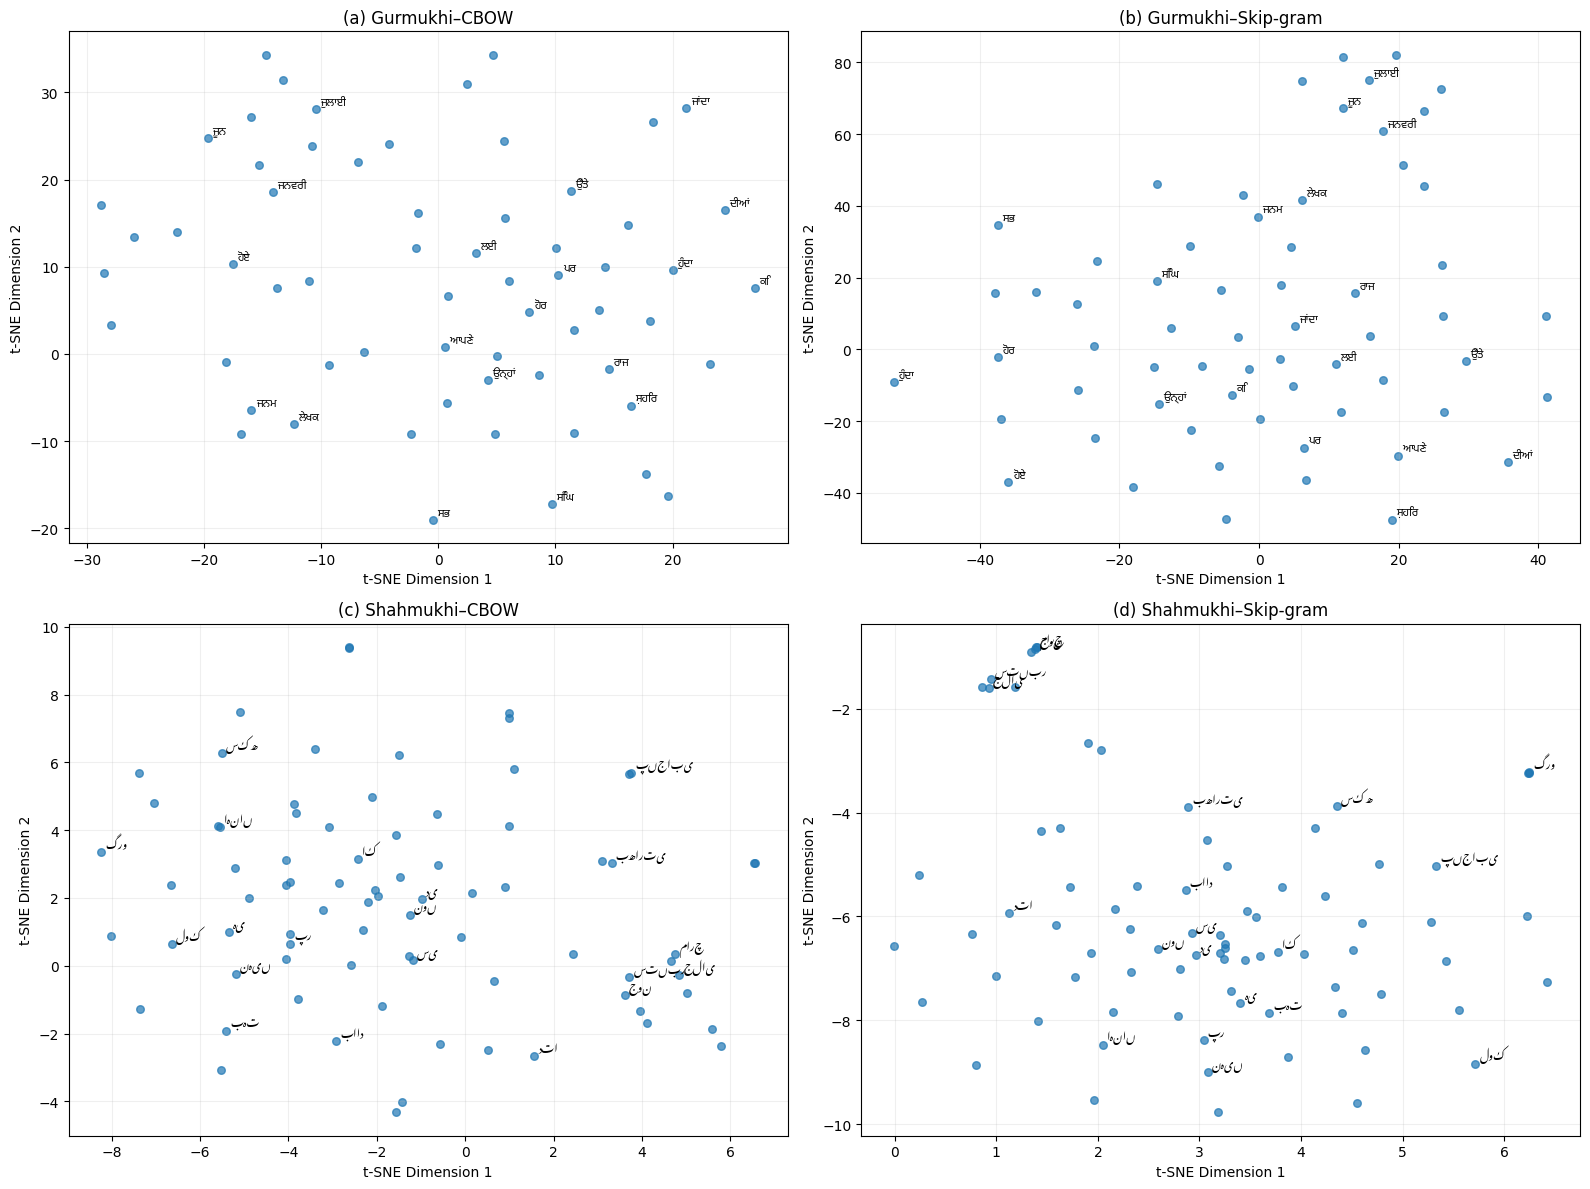

In [890]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from sklearn.manifold import TSNE

# Font paths in Google Colab
GURMUKHI_FONT = FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoSansGurmukhi-Regular.ttf"
)

SHAHMUKHI_FONT = FontProperties(
    fname="/usr/share/fonts/truetype/noto/NotoNastaliqUrdu-Regular.ttf"
)


def plot_tsne_panel(
    ax,
    model,
    words,
    title,
    script,
    label_count=20
):
    vectors = np.array([model.wv[word] for word in words])

    tsne = TSNE(
        n_components=2,
        perplexity=15,
        random_state=42,
        init="pca",
        learning_rate="auto",
        max_iter=1500
    )

    coordinates = tsne.fit_transform(vectors)

    ax.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        alpha=0.7,
        s=30
    )

    label_font = (
        GURMUKHI_FONT
        if script == "gurmukhi"
        else SHAHMUKHI_FONT
    )

    # Choose reproducible random words for labels
    rng = np.random.default_rng(42)
    label_count = min(label_count, len(words))
    label_indices = rng.choice(
        len(words),
        size=label_count,
        replace=False
    )

    for i in label_indices:
        ax.annotate(
            words[i],
            (coordinates[i, 0], coordinates[i, 1]),
            fontsize=8,
            fontproperties=label_font,
            xytext=(3, 3),
            textcoords="offset points"
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_tsne_panel(
    axes[0, 0],
    gurmukhi_cbow,
    gurmukhi_words,
    "(a) Gurmukhi–CBOW",
    script="gurmukhi"
)

plot_tsne_panel(
    axes[0, 1],
    gurmukhi_skipgram,
    gurmukhi_words,
    "(b) Gurmukhi–Skip-gram",
    script="gurmukhi"
)

plot_tsne_panel(
    axes[1, 0],
    shahmukhi_cbow,
    shahmukhi_words,
    "(c) Shahmukhi–CBOW",
    script="shahmukhi"
)

plot_tsne_panel(
    axes[1, 1],
    shahmukhi_skipgram,
    shahmukhi_words,
    "(d) Shahmukhi–Skip-gram",
    script="shahmukhi"
)

plt.tight_layout()

fig.savefig(
    "Figure_3_tSNE_Punjabi_Embeddings.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [892]:
plt.tight_layout()

# Save the figure
fig.savefig(
    "Figure_3_tSNE_Punjabi_Embeddings.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# Display the figure
plt.show()

/tmp/ipykernel_23808/821625021.py:4: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gurmukhi.
  fig.savefig(
/tmp/ipykernel_23808/821625021.py:4: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gurmukhi.
  fig.savefig(
/tmp/ipykernel_23808/821625021.py:4: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  fig.savefig(
/tmp/ipykernel_23808/821625021.py:4: UserWarning: Glyph 112 (p) missing from font(s) Noto Nastaliq Urdu.
  fig.savefig(


<Figure size 640x480 with 0 Axes>

In [873]:
GURMUKHI_FONT = font_manager.FontProperties(
    family="Noto Sans Gurmukhi"
)

SHAHMUKHI_FONT = font_manager.FontProperties(
    family="Noto Nastaliq Urdu"
)

In [874]:
def plot_pca_panel(
    ax,
    model,
    words,
    title,
    script,
    label_count=20
):
    vectors = np.array([model.wv[word] for word in words])

    pca = PCA(n_components=2)
    coordinates = pca.fit_transform(vectors)

    ax.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        alpha=0.7,
        s=30
    )

    label_font = (
        GURMUKHI_FONT
        if script == "gurmukhi"
        else SHAHMUKHI_FONT
    )

    for i, word in enumerate(words[:label_count]):
        ax.annotate(
            word,
            (coordinates[i, 0], coordinates[i, 1]),
            fontsize=8,
            fontproperties=label_font,
            xytext=(3, 3),
            textcoords="offset points"
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.2)

/tmp/ipykernel_23808/726313173.py:35: UserWarning: Glyph 2598 (\N{GURMUKHI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23808/726313173.py:35: UserWarning: Matplotlib currently does not support Gurmukhi natively.
  plt.tight_layout()
/tmp/ipykernel_23808/726313173.py:35: UserWarning: Glyph 2631 (\N{GURMUKHI VOWEL SIGN EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23808/726313173.py:35: UserWarning: Glyph 2622 (\N{GURMUKHI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23808/726313173.py:35: UserWarning: Glyph 2613 (\N{GURMUKHI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23808/726313173.py:35: UserWarning: Glyph 2623 (\N{GURMUKHI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23808/726313173.py:35: UserWarning: Glyph 2673 (\N{GURMUKHI ADDAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykern

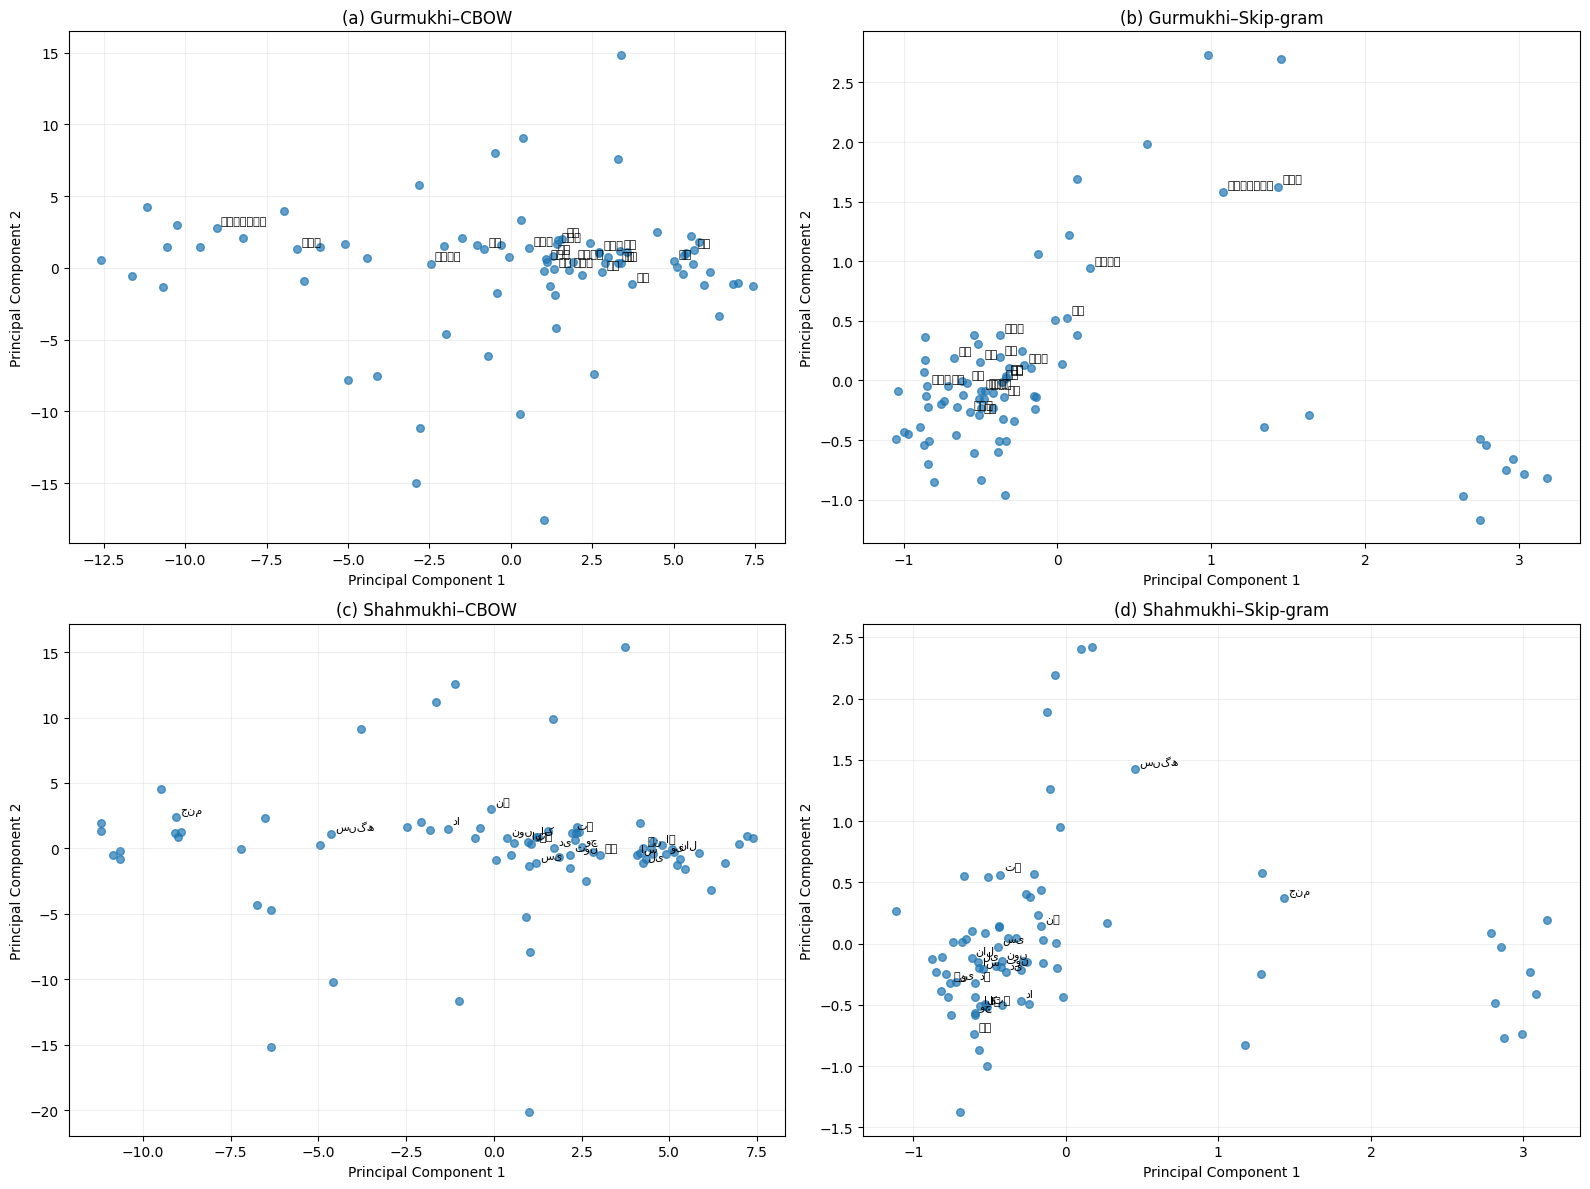

In [875]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_pca_panel(
    axes[0, 0],
    gurmukhi_cbow,
    gurmukhi_words,
    "(a) Gurmukhi–CBOW",
    script="gurmukhi"
)

plot_pca_panel(
    axes[0, 1],
    gurmukhi_skipgram,
    gurmukhi_words,
    "(b) Gurmukhi–Skip-gram",
    script="gurmukhi"
)

plot_pca_panel(
    axes[1, 0],
    shahmukhi_cbow,
    shahmukhi_words,
    "(c) Shahmukhi–CBOW",
    script="shahmukhi"
)

plot_pca_panel(
    axes[1, 1],
    shahmukhi_skipgram,
    shahmukhi_words,
    "(d) Shahmukhi–Skip-gram",
    script="shahmukhi"
)

plt.tight_layout()
plt.savefig(
    "Figure_2_PCA_Punjabi_Embeddings.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [876]:
from matplotlib import font_manager

fonts = sorted(set(f.name for f in font_manager.fontManager.ttflist))

for f in fonts:
    if "Noto" in f or "Gurmukhi" in f or "Urdu" in f or "Arabic" in f:
        print(f)

In [877]:
gurmukhi_stopwords = {
    "ਦਾ","ਦੀ","ਦੇ","ਨੂੰ","ਹੈ","ਸੀ","ਇੱਕ","ਤੇ","ਵਿੱਚ","ਨਾਲ",
    "ਤੋਂ","ਇਹ","ਉਹ","ਨੇ","ਵੀ","ਹੋ","ਕਰ","ਜਾਂ","ਕੀ"
}

gurmukhi_words = [
    w for w in gurmukhi_words
    if w not in gurmukhi_stopwords
]

In [878]:
from matplotlib import font_manager

for path in font_manager.findSystemFonts():
    if "Gurmukhi" in path or "gurmukhi" in path:
        print(path)

/usr/share/fonts/truetype/noto/NotoSansGurmukhi-ExtraCondensedMedium.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhiUI-SemiCondensedLight.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhiUI-SemiBold.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-CondensedMedium.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-ExtraLight.ttf
/usr/share/fonts/truetype/noto/NotoSerifGurmukhi-Regular.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-ExtraCondensedLight.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-SemiCondensedExtraLight.ttf
/usr/share/fonts/truetype/noto/NotoSerifGurmukhi-Bold.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-SemiCondensedThin.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-Condensed.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-SemiCondensedBold.ttf
/usr/share/fonts/truetype/noto/NotoSerifGurmukhi-Medium.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhiUI-SemiCondensedExtraLight.ttf
/usr/share/fonts/truetype/noto/NotoSansGurmukhi-Light

In [883]:
plt.tight_layout()

plt.savefig(
    "Figure_2_PCA_Punjabi_Embeddings.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [884]:
plt.tight_layout()

plt.savefig(
    "Figure_3_tSNE_Punjabi_Embeddings.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [885]:
from google.colab import files

files.download("Figure_2_PCA_Punjabi_Embeddings.png")
files.download("Figure_3_tSNE_Punjabi_Embeddings.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>